# YOLOv11 로컬 학습 노트북

In [1]:
# Cell 1: GPU 확인
import torch
print('GPU 사용 가능:', torch.cuda.is_available())
print('GPU 이름:', torch.cuda.get_device_name(0))

GPU 사용 가능: True
GPU 이름: NVIDIA GeForce RTX 2080


In [2]:
# Cell 2: 작업 폴더 설정
import os
WORK_DIR = os.path.expanduser('~/다운로드/인공지능프로젝트/YOLO_jupyters/yolo_local_v13_0629')
os.chdir(WORK_DIR)
print('작업 폴더:', WORK_DIR)

작업 폴더: /home/piai/다운로드/인공지능프로젝트/YOLO_jupyters/yolo_local_v13_0629


In [3]:
# Cell 3: 파일 확인
import os
WORK_DIR = os.path.expanduser('~/다운로드/인공지능프로젝트/YOLO_jupyters/yolo_local_v13_0629')
for item in os.listdir(WORK_DIR):
    print(item)

In [4]:
# 새 환경이라 roboflow, ultralytics 먼저 설치
import subprocess
subprocess.run(['pip', 'install', 'roboflow', 'ultralytics'], check=True)

# roboflow 라이브러리에서 Roboflow 클래스 불러오기
from roboflow import Roboflow

# API 키로 Roboflow 계정에 로그인
rf = Roboflow(api_key="byjMEhXUKbKas3eLE2V9")

# 워크스페이스(elecourse-atjrg) 안의 프로젝트(merge_0626_3)에 접근
project = rf.workspace("elecourse-atjrg").project("merge_0626_3")

# 해당 프로젝트의 13번 버전 선택
version = project.version(13)

# YOLOv11 형식으로 데이터셋 다운로드 → 인공지능프로젝트 폴더에 저장됨
import os
os.chdir(os.path.expanduser('~/다운로드/인공지능프로젝트/YOLO_jupyters/yolo_local_v13_0629'))
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to merge_0626_3-13 in yolov11:: 100%|██████████| 6439/6439 [00:00<00:00, 8044.09it/s]


In [5]:
# 인공지능프로젝트 폴더 안의 파일 목록 확인
import os
for item in os.listdir(os.path.expanduser('~/다운로드/인공지능프로젝트/YOLO_jupyters/yolo_local_v13_0629')):
    print(item)

merge_0626_3-13


In [6]:
# ultralytics에서 YOLO 클래스 불러오기
from ultralytics import YOLO

import os
WORK_DIR = os.path.expanduser('~/다운로드/인공지능프로젝트/YOLO_jupyters/yolo_local_v13_0629')

# yolo11m.pt 모델 로드
model = YOLO(os.path.join(WORK_DIR, 'yolo11m.pt'))

# 모델 학습 시작
train_result = model.train(
    data=os.path.join(WORK_DIR, 'merge_0626_3-13/data.yaml'),
    epochs=100,
    imgsz=640,
    batch=16,
    name="dell7920_v1",
    project=os.path.join(WORK_DIR, 'runs/detect')
)

# 학습 결과 폴더에서 best.pt 경로 자동 저장
# (같은 name으로 여러 번 돌리면 dell7920_v1-2, -3 ... 자동 생성되므로 직접 잡아줌)
MODEL_PATH = os.path.join(str(train_result.save_dir), 'weights', 'best.pt')
print('학습된 모델 경로:', MODEL_PATH)


New https://pypi.org/project/ultralytics/8.4.82 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.80 🚀 Python-3.11.15 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2080, 7785MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/piai/다운로드/인공지능프로젝트/YOLO_jupyters/yolo_local_v13_0629/merge_0626_3-13/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=tr

In [8]:
# 학습 결과 mAP 점수 확인 (best.pt 기준)
from ultralytics import YOLO
import os

WORK_DIR = os.path.expanduser('~/다운로드/인공지능프로젝트/YOLO_jupyters/yolo_local_v13_0629')

# MODEL_PATH가 앞 셀에서 자동 설정된 경우 그대로 사용,
# 이 셀만 단독 실행할 경우 아래 경로를 직접 입력
if 'MODEL_PATH' not in dir():
    MODEL_PATH = os.path.join(WORK_DIR, 'runs/detect/dell7920_v1/weights/best.pt')  # ← 필요 시 수정

best_model = YOLO(MODEL_PATH)
metrics = best_model.val(data=os.path.join(WORK_DIR, 'merge_0626_3-13/data.yaml'))
print('mAP@50:', metrics.box.map50)
print('mAP@50-95:', metrics.box.map)
# 0.8 이상 → 좋음
# 0.5~0.8 → 데이터 추가 필요
# 0.5 미만 → 라벨링 품질 점검 필요


Ultralytics 8.4.80 🚀 Python-3.11.15 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2080, 7785MiB)
YOLO11m summary (fused): 126 layers, 20,035,429 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1951.0±356.5 MB/s, size: 54.7 KB)
val: Scanning /home/piai/다운로드/인공지능프로젝트/YOLO_jupyters/yolo_local_v13_0629/merge_0626_3-13/valid/labels.cache... 137 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 137/137 44.2Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 10, len(boxes) = 447. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.9it/s 3.1s0.3s
                   all        137        447      0.844      0.834      0.858      0.587
                   GPU         18         23      0.674 

## 추론: 이미지에 바운딩 박스 시각화

학습된 best.pt 모델로 이미지를 추론하고, VSCode 환경에서 결과를 인라인 이미지로 확인합니다.

In [20]:
%matplotlib inline

In [17]:
import os

WORK_DIR = os.path.expanduser('~/다운로드/인공지능프로젝트/YOLO_jupyters/yolo_local_v13_0629')

if 'MODEL_PATH' not in dir():
    MODEL_PATH = os.path.join(WORK_DIR, 'runs/detect/dell7920_v1/weights/best.pt')  # ← 필요 시 수정

IMAGE_PATH = '/home/piai/다운로드/인공지능프로젝트/YOLO_jupyters/20260628_190121.jpg'
CONF_THRESHOLD = 0.25

print('모델 경로:', MODEL_PATH)
print('이미지 경로:', IMAGE_PATH)
print('모델 파일 존재:', os.path.exists(MODEL_PATH))
print('이미지 파일 존재:', os.path.exists(IMAGE_PATH))

모델 경로: /home/piai/다운로드/인공지능프로젝트/YOLO_jupyters/yolo_local_v13_0629/runs/detect/dell7920_v1/weights/best.pt
이미지 경로: /home/piai/다운로드/인공지능프로젝트/YOLO_jupyters/20260628_190121.jpg
모델 파일 존재: True
이미지 파일 존재: True


모델 로드 완료
Results saved to /home/piai/다운로드/인공지능프로젝트/YOLO_jupyters/yolo_local_v13_0629/inference_out/images


Glyph 53456 (\N{HANGUL SYLLABLE TAM}) missing from font(s) DejaVu Sans.
Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.


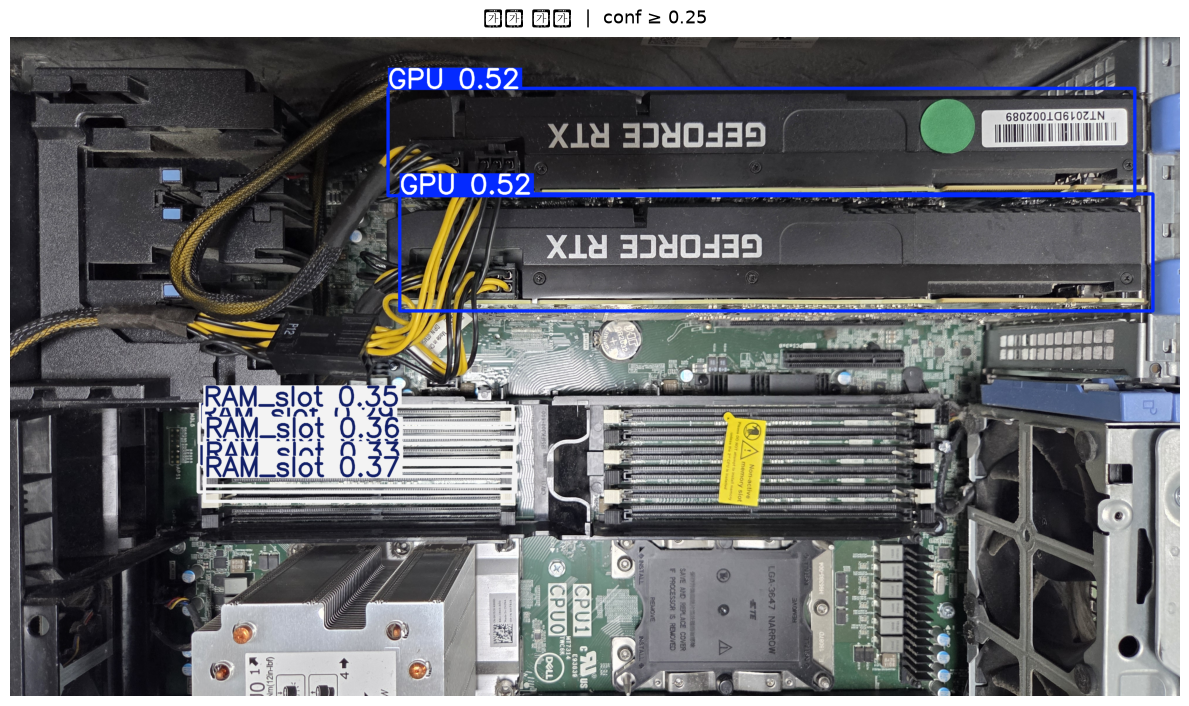

저장 위치: /home/piai/다운로드/인공지능프로젝트/YOLO_jupyters/yolo_local_v13_0629/inference_out/images/


In [23]:
from ultralytics import YOLO
import matplotlib.pyplot as plt


model = YOLO(MODEL_PATH)
print('모델 로드 완료')

results = model.predict(
    source=IMAGE_PATH,
    conf=CONF_THRESHOLD,
    save=True,
    project=os.path.join(WORK_DIR, 'inference_out'),
    name='images',
    exist_ok=True,
    verbose=False,  # YOLO 자체 출력 끄기
    show=False      # YOLO 자체 미리보기 끄기
)
result = results[0]
img_rgb = result.plot()[:, :, ::-1]  # BGR → RGB

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(img_rgb)
ax.axis('off')
ax.set_title(f'탐지 결과  |  conf ≥ {CONF_THRESHOLD}', fontsize=13, pad=10)
plt.tight_layout()
plt.show()

print('저장 위치:', os.path.join(WORK_DIR, 'inference_out/images/'))
plt.show() 

In [22]:
CLASS_NAMES = model.names

boxes = result.boxes
if boxes is None or len(boxes) == 0:
    print('탐지된 객체 없음')
else:
    print(f'총 {len(boxes)}개 객체 탐지됨\n')
    print(f'{"#":<4} {"클래스":<20} {"신뢰도":>8}  {"바운딩 박스 (x1,y1,x2,y2)"}')
    print('-' * 65)
    for i, box in enumerate(boxes):
        cls_id   = int(box.cls[0])
        conf_val = float(box.conf[0])
        x1, y1, x2, y2 = [round(float(v), 1) for v in box.xyxy[0]]
        print(f'{i+1:<4} {CLASS_NAMES[cls_id]:<20} {conf_val:>7.1%}  ({x1}, {y1}, {x2}, {y2})')

총 9개 객체 탐지됨

#    클래스                       신뢰도  바운딩 박스 (x1,y1,x2,y2)
-----------------------------------------------------------------
1    GPU                    52.0%  (1332.6, 535.8, 3907.2, 935.7)
2    GPU                    51.8%  (1292.4, 174.9, 3845.6, 541.1)
3    RAM_slot               37.0%  (664.9, 1501.1, 1720.1, 1586.9)
4    RAM_slot               36.0%  (665.1, 1367.5, 1726.0, 1446.8)
5    RAM_slot               34.9%  (661.4, 1260.7, 1719.8, 1334.4)
6    RAM_slot               33.0%  (667.0, 1452.0, 1722.9, 1533.2)
7    RAM_slot               30.0%  (664.4, 1388.5, 1724.3, 1480.9)
8    RAM_slot               29.1%  (646.5, 1319.7, 1733.7, 1388.9)
9    RAM_slot               28.7%  (643.8, 1460.8, 1729.8, 1555.0)


## 추론: 영상(Video)에 바운딩 박스 시각화

In [ ]:
# Cell: 영상 추론 설정
import os

WORK_DIR = os.path.expanduser('~/다운로드/인공지능프로젝트/YOLO_jupyters/yolo_local_v13_0629')

# 학습 셀을 실행했다면 MODEL_PATH가 자동으로 설정되어 있음
# 이 셀만 단독 실행할 경우 아래 경로를 직접 입력
if 'MODEL_PATH' not in dir():
    MODEL_PATH = os.path.join(WORK_DIR, 'runs/detect/dell7920_v1/weights/best.pt')  # ← 필요 시 수정

# 추론할 영상 경로 (mp4, mov, avi 등)
VIDEO_PATH = os.path.join(WORK_DIR, 'test_video.mp4')  # ← 여기에 실제 영상 경로 입력

# 결과 영상 저장 폴더
VIDEO_OUT_DIR = os.path.join(WORK_DIR, 'video_out')
os.makedirs(VIDEO_OUT_DIR, exist_ok=True)

CONF_THRESHOLD = 0.25

print('모델 경로 :', MODEL_PATH)
print('영상 경로 :', VIDEO_PATH)
print('결과 저장 :', VIDEO_OUT_DIR)
print('모델 존재 :', os.path.exists(MODEL_PATH))
print('영상 존재 :', os.path.exists(VIDEO_PATH))


In [ ]:
# Cell: 영상 추론 실행 → 결과 영상 저장
# 처리 완료 후 VIDEO_OUT_DIR/run/ 안에 박스 그려진 mp4가 생성됩니다
from ultralytics import YOLO

model = YOLO(MODEL_PATH)

results = model.predict(
    source=VIDEO_PATH,
    conf=CONF_THRESHOLD,
    save=True,            # 결과 영상 저장
    project=VIDEO_OUT_DIR,
    name='run',
    exist_ok=True,
    verbose=True,
    stream=True           # 메모리 절약: 프레임을 한 번에 다 올리지 않고 스트리밍
)

# stream=True 이면 generator이므로 순회해야 실제로 처리됨
frame_count = 0
for r in results:
    frame_count += 1

print(f'\n처리 완료: {frame_count}프레임')
print(f'결과 저장 위치: {VIDEO_OUT_DIR}/run/')


In [ ]:
# Cell: 결과 영상에서 대표 프레임 미리보기 (균등 간격으로 N장)
import cv2
import glob
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')

PREVIEW_N = 6  # 미리볼 프레임 수

# 저장된 결과 영상 찾기
saved_videos = glob.glob(os.path.join(VIDEO_OUT_DIR, 'run', '*.mp4')) + \
               glob.glob(os.path.join(VIDEO_OUT_DIR, 'run', '*.avi'))

if not saved_videos:
    print('결과 영상을 찾을 수 없습니다. 위 셀을 먼저 실행하세요.')
else:
    out_video_path = saved_videos[0]
    print('미리보기 대상:', out_video_path)

    cap = cv2.VideoCapture(out_video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps          = cap.get(cv2.CAP_PROP_FPS)
    w            = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h            = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    print(f'총 프레임: {total_frames}  |  FPS: {fps:.1f}  |  해상도: {w}x{h}')

    # 균등 간격 프레임 인덱스 선택
    indices = [int(total_frames * i / PREVIEW_N) for i in range(PREVIEW_N)]

    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frames.append((idx, frame[:, :, ::-1]))  # BGR → RGB
    cap.release()

    cols = 3
    rows = (len(frames) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes.flatten()

    for i, (ax, (idx, img)) in enumerate(zip(axes, frames)):
        ax.imshow(img)
        ax.axis('off')
        t = idx / fps if fps > 0 else 0
        ax.set_title(f'frame {idx}  ({t:.1f}s)', fontsize=9)

    for ax in axes[len(frames):]:
        ax.set_visible(False)

    plt.suptitle(f'결과 영상 미리보기  |  conf ≥ {CONF_THRESHOLD}', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()


In [ ]:
# Cell: 웹캠 실시간 추론 (선택 사항)
# VSCode 터미널에서 실행하는 것을 권장합니다.
# Jupyter 셀에서 실행하면 창이 열리지 않을 수 있습니다.
#
# 사용법: 아래 코드 블록의 주석을 해제하고 실행하세요.
# 종료: 영상 창에서 'q' 키를 누르세요.

# import cv2
# from ultralytics import YOLO
#
# model = YOLO(MODEL_PATH)
#
# cap = cv2.VideoCapture(0)  # 0 = 기본 웹캠, 1·2 = 외부 카메라
# cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
# cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)
#
# print('웹캠 추론 시작 — 창에서 q 키를 눌러 종료')
# while True:
#     ret, frame = cap.read()
#     if not ret:
#         break
#
#     results = model.predict(frame, conf=CONF_THRESHOLD, verbose=False)
#     annotated = results[0].plot()
#
#     cv2.imshow('YOLO11m 실시간 추론  (q: 종료)', annotated)
#     if cv2.waitKey(1) & 0xFF == ord('q'):
#         break
#
# cap.release()
# cv2.destroyAllWindows()
# print('종료')

print('웹캠 셀은 주석 처리된 상태입니다.')
print('사용하려면 위 주석(#)을 모두 해제하고 실행하세요.')
